# Proyek Klasifikasi Gambar: [Klasifikasi Gambar Hewan menggunakan CNN]
- **Nama:** [Uray Ayuni Sevrilian]
- **Email:** [ayunilian99@gmail.com]
- **ID Dicoding:** [ayunisev]

Proyek ini bertujuan untuk mengklasifikasikan gambar hewan ke dalam 10 kelas hewan. Model dibuat dengan menggunakan MobileNetV2 berbasis transfer learning.

Dataset yang digunakan : https://www.kaggle.com/datasets/alessiocorrado99/animals10/data

## Import Semua Packages/Library yang Digunakan

In [1]:
# Mengimpor libraries umum yang sering digunakan
import os
import zipfile
import random
from random import sample
import numpy as np
import pandas as pd

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Mengimpor libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Mengimpor libraries untuk pembuatan dan evaluasi model
!pip install tensorflow
!pip install keras

import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

## Data Preparation

### Data Loading

In [3]:
# upload file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayuniayu","key":"ec75592f431de57ac4fcf48abe5b1e20"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d alessiocorrado99/animals10
!unzip -o animals10.zip
!ls
!ls raw-img | head

Streaming output truncated to the last 5000 lines.
  inflating: raw-img/ragno/OIP-MgrKq05YHGXsgj1AmYIyJQHaE8.jpeg  
  inflating: raw-img/ragno/OIP-MhRGx7d8nbnHBuqrsO00EQHaFo.jpeg  
  inflating: raw-img/ragno/OIP-MiVgMXcKGQdog2KGe7i0YQHaHh.jpeg  
  inflating: raw-img/ragno/OIP-Mis0lJf3Xbf3ulUg4DQ_EwHaFz.jpeg  
  inflating: raw-img/ragno/OIP-Mj15wALS_srxPktt6trhhQHaGA.jpeg  
  inflating: raw-img/ragno/OIP-Mj_JhYslbL_Xbj5lBBziagHaFb.jpeg  
  inflating: raw-img/ragno/OIP-MktEsZ9eQtFDPLU71DNOAwHaEh.jpeg  
  inflating: raw-img/ragno/OIP-Ml7Od1dGkqkJgXpJDpC0dQHaFj.jpeg  
  inflating: raw-img/ragno/OIP-MmB9gn8-sdjLQTpPv6ik3AEsDw.jpeg  
  inflating: raw-img/ragno/OIP-MmoKpEIgWJOoQZux8LtrcgHaGd.jpeg  
  inflating: raw-img/ragno/OIP-Mnup5kCuX4fDtL-4c1nPBAHaFG.jpeg  
  inflating: raw-img/ragno/OIP-MoHsdM75gQrv0NYl1aifewAAAA.jpeg  
  inflating: raw-img/ragno/OIP-MobhPjsXyp_M_L7aVfjBTgHaFj.jpeg  
  inflating: raw-img/ragno/OIP-MpWY8USoo7z6Ul6gsox6hwHaFB.jpeg  
  inflating: raw-img/ragno/OIP-MqT6ows3

In [5]:
translate = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "scoiattolo": "squirrel",
    "dog": "cane",
    "cavallo": "horse",
    "elephant" : "elefante",
    "butterfly": "farfalla",
    "chicken": "gallina",
    "cat": "gatto",
    "cow": "mucca",
    "spider": "ragno",
    "squirrel": "scoiattolo"
}
# en = {v: x for x, v in translate.items()}

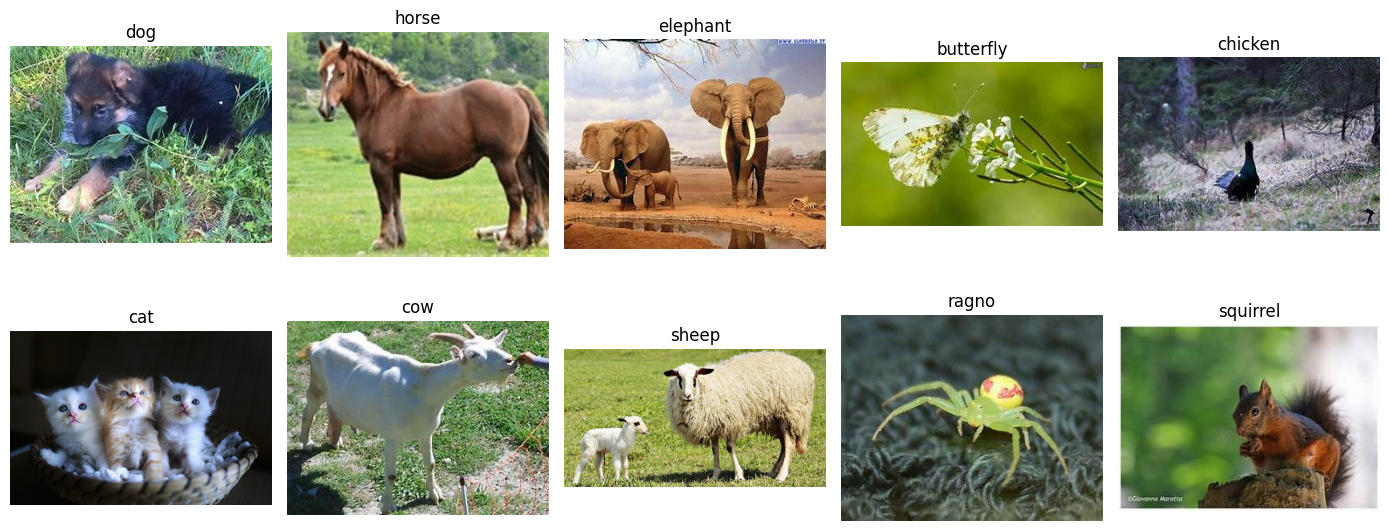

In [6]:
# Lihat 10 kelas animal
folder_raw = '/content/raw-img'
extensi_gambar = ('.jpg', '.jpeg', '.png')

daftar_kelas = sorted([
    x for x in os.listdir(folder_raw)
    if os.path.isdir(os.path.join(folder_raw, x))
])

daftar_kelas = daftar_kelas[:10]

plt.figure(figsize=(14, 6))

for i, folder in enumerate(daftar_kelas):
    path_kelas = os.path.join(folder_raw, folder)

    daftar_gambar = [
        f for f in os.listdir(path_kelas)
        if f.lower().endswith(extensi_gambar)
    ]

    plt.subplot(2, 5, i + 1)
    plt.axis("off")

    if len(daftar_gambar) == 0:
        plt.title(f"{folder}\n(kosong)")
        continue

    file_acak = random.choice(daftar_gambar)
    gambar = Image.open(os.path.join(path_kelas, file_acak))

    judul = translate.get(folder, folder)
    plt.title(judul)
    plt.imshow(gambar)

plt.tight_layout()
plt.show()

In [8]:
# Cek resolusi gambar
from PIL import Image
import os

def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if not os.path.isdir(subdir_path):
            continue

        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f"{subdir}: {num_images} gambar")
        total_images += num_images

        for img_file in image_files:
            img_path = os.path.join(subdir_path, img_file)
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)

        for size in unique_sizes:
            print(f"- {size}")
        print("-------batas akhir--------")

    print(f"\nTotal: {total_images}")

print_images_resolution('/content/raw-img')

Streaming output truncated to the last 5000 lines.
- (243, 300)
- (300, 215)
- (221, 300)
- (640, 512)
- (199, 132)
- (640, 521)
- (640, 530)
- (640, 539)
- (290, 179)
- (240, 160)
- (300, 300)
- (120, 104)
- (120, 113)
- (183, 300)
- (194, 300)
- (640, 377)
- (470, 640)
- (640, 386)
- (640, 395)
- (150, 150)
- (182, 182)
- (640, 404)
- (300, 165)
- (262, 300)
- (640, 413)
- (251, 300)
- (300, 174)
- (265, 216)
- (290, 300)
- (300, 183)
- (285, 194)
- (300, 192)
- (300, 201)
- (640, 507)
- (224, 300)
- (213, 300)
- (250, 200)
- (640, 516)
- (280, 210)
- (500, 640)
- (252, 300)
- (120, 90)
- (489, 640)
- (300, 295)
- (220, 186)
- (240, 164)
- (640, 372)
- (175, 300)
- (249, 249)
- (640, 381)
- (290, 259)
- (640, 390)
- (462, 640)
- (640, 399)
- (300, 160)
- (290, 277)
- (640, 408)
- (300, 169)
- (253, 246)
- (282, 282)
- (300, 178)
- (5403, 3602)
- (300, 187)
- (530, 640)
- (271, 300)
- (282, 300)
- (300, 196)
- (293, 300)
- (277, 194)
- (424, 640)
- (640, 493)
- (640, 502)
- (640, 511)

### Data Preprocessing

#### Split Dataset

In [9]:
import os
from collections import defaultdict
from sklearn.model_selection import train_test_split
import shutil

src_dir = '/content/raw-img'
dst_dir = '/content/animals10_split'

seed = 42
ext_img = ('.jpg', '.jpeg', '.png')

# berfungsi untuk reset output
if os.path.exists(dst_dir):
  shutil.rmtree(dst_dir)

# berfungsi untuk daftar kelas diambil dari folder utama
classe = sorted([x for x in os.listdir(src_dir) if os.path.isdir(os.path.join(src_dir,x))])

# berfungsi untuk kumpul file per kelas
by_class = defaultdict(list)
for c in classe:
  path = os.path.join(src_dir,c)
  for fn in os.listdir(path):
    if fn.lower().endswith(ext_img):
      by_class[c].append(os.path.join(path,fn))

  # split 70/15/15

# val = 0.15 total sisa setelah test = 0.85 total jadi ukuran val relatif terhadap sisa = 0.15 / 0.85 ≈ 0.17647
val_sisa = 0.15/0.85

total_train = total_val = total_test = 0
for c, files in by_class.items():
  tr,te = train_test_split(files,test_size=0.15,random_state=seed, shuffle=True)
  tr,va = train_test_split(tr,test_size=val_sisa,random_state=seed, shuffle=True)

  total_train += len(tr); total_val += len(va); total_test += len(te)

  for split, group in (('train',tr), ('val',va), ('test',te)):
    for src in group:
      out = os.path.join(dst_dir, split, c, os.path.basename(src))
      # Create destination directory if it doesn't exist
      os.makedirs(os.path.dirname(out), exist_ok=True)
      if os.path.exists(out):
        b, e = os.path.splitext(out)
        out = f"{b}_{abs(hash(src)) % 10000}{e}"
      shutil.copy2(src, out)

print("split ke file:", dst_dir)
print("Train:", total_train, "Val:", total_val, "Test:", total_test, "Total:", total_train+total_val+total_test)

split ke file: /content/animals10_split
Train: 18318 Val: 3930 Test: 3931 Total: 26179


#### Image Data Generator

Model menggunakan MobileNetV2 pretrained ImageNet sebagai backbone dan menerapkan transfer learning dengan 10 kelas, MobileNetV2 mampu mengekstraksi fitur gambar dengan baik.

In [10]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = "/content/animals10_split"
IMG_SIZE = (224, 224)
BATCH = 32

prep = tf.keras.applications.mobilenet_v2.preprocess_input

train_gen = ImageDataGenerator(
    preprocessing_function=prep,
    rotation_range=20, #gambar diputar acak sampai 20 derajat
    zoom_range=0.2, # Zoom in/out acak sampai 20%
    width_shift_range=0.1, #geser kiri/kanan sampai 10% lebar gambar
    height_shift_range=0.1, #geser atas/bawah sampai 10% tinggi gambar
    horizontal_flip=True, # dibalik kiri kanan secara acak
    fill_mode="nearest" # supaya gambar tidak bolong
)

eval_gen = ImageDataGenerator(preprocessing_function=prep)

train_data = train_gen.flow_from_directory(
    os.path.join(base_dir, "train"), #folder train
    target_size=IMG_SIZE, #resize ke 224 x 224
    batch_size=BATCH, # ambil 32 per batch
    class_mode="categorical", # dibuat one hot
    shuffle=True # data train diacak
)

val_data = eval_gen.flow_from_directory( # berfungsi tnpa augmentasi
    os.path.join(base_dir, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

test_data = eval_gen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

Found 18318 images belonging to 10 classes.
Found 3930 images belonging to 10 classes.
Found 3931 images belonging to 10 classes.


## Modelling

In [11]:
from tensorflow.keras.layers import (Conv2D, MaxPooling2D,
                                     GlobalAveragePooling2D,
                                     Dense, Dropout, BatchNormalization)

# Backbone MobileNetV2 (transfer learning)

base = tf.keras.applications.MobileNetV2(
    input_shape = (224, 224, 3),
    include_top = False,
    weights = 'imagenet'
)
base.trainable = False

model = Sequential([
    base,

    # berfungsi ektrasi fitur gambar
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(), #normalisasi
    MaxPooling2D(2,2), # mengecilkan ukuran feature map jadi ambil nilai maksmum

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # classifier
    GlobalAveragePooling2D(),
    Dropout(0.4), #mengurangi overfitting
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(train_data.num_classes, activation='softmax') #ambil kelas di train data
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,539,530 (21.13 MB)

 Trainable params: 3,280,778 (12.52 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6)
]

#### train dan testing

In [13]:
# cek kelas
print("num_classes:", train_data.num_classes)
print("class_indices:", train_data.class_indices)

num_classes: 10
class_indices: {'cane': 0, 'cavallo': 1, 'elefante': 2, 'farfalla': 3, 'gallina': 4, 'gatto': 5, 'mucca': 6, 'pecora': 7, 'ragno': 8, 'scoiattolo': 9}


Fase 1 Transfer Learning

In [14]:
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 278s 445ms/step - accuracy: 0.8462 - loss: 0.5189 - val_accuracy: 0.9534 - val_loss: 0.1586 - learning_rate: 0.0010
Epoch 2/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 223s 389ms/step - accuracy: 0.9286 - loss: 0.2383 - val_accuracy: 0.9450 - val_loss: 0.2069 - learning_rate: 0.0010
Epoch 3/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 220s 385ms/step - accuracy: 0.9418 - loss: 0.1885 - val_accuracy: 0.9522 - val_loss: 0.1676 - learning_rate: 0.0010
Epoch 4/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 223s 389ms/step - accuracy: 0.9494 - loss: 0.1691 - val_accuracy: 0.9560 - val_loss: 0.1597 - learning_rate: 0.0010
Epoch 5/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 222s 388ms/step - accuracy: 0.9568 - loss: 0.1389 - val_accuracy: 0.9644 - val_loss: 0.1301 - learning_rate: 5.0000e-04
Epoch 6/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 220s 384ms/step - accuracy: 0.9624 - loss: 0.1184 - val_accuracy: 0.9595 - val_loss: 0.1473 - learning_rate: 5.0000e-04
Epoch 7/15
573/573 ━━━━━━━━━━━━━━━━━━━━ 225s 392ms/step 

Fase 2 Fine Tuning

In [16]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 260s 421ms/step - accuracy: 0.9688 - loss: 0.0956 - val_accuracy: 0.9649 - val_loss: 0.1236 - learning_rate: 1.0000e-05
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 223s 389ms/step - accuracy: 0.9698 - loss: 0.0940 - val_accuracy: 0.9659 - val_loss: 0.1269 - learning_rate: 1.0000e-05
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 249s 434ms/step - accuracy: 0.9744 - loss: 0.0838 - val_accuracy: 0.9651 - val_loss: 0.1235 - learning_rate: 1.0000e-05
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 269s 469ms/step - accuracy: 0.9728 - loss: 0.0862 - val_accuracy: 0.9646 - val_loss: 0.1299 - learning_rate: 1.0000e-05
Epoch 5/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 234s 409ms/step - accuracy: 0.9775 - loss: 0.0704 - val_accuracy: 0.9646 - val_loss: 0.1302 - learning_rate: 5.0000e-06
Epoch 6/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 231s 404ms/step - accuracy: 0.9775 - loss: 0.0764 - val_accuracy: 0.9659 - val_loss: 0.1283 - learning_rate: 5.0000e-06
Epoch 7/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 

In [17]:
train_loss, train_acc = model.evaluate(train_data, verbose=1)
test_loss, test_acc   = model.evaluate(test_data, verbose=1)

print("Train accuracy:", train_acc)
print("Test  accuracy:", test_acc)

573/573 ━━━━━━━━━━━━━━━━━━━━ 227s 396ms/step - accuracy: 0.9919 - loss: 0.0306
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.9693 - loss: 0.0988
Train accuracy: 0.9914292097091675
Test  accuracy: 0.9674383401870728


Output akurasi train dan test:

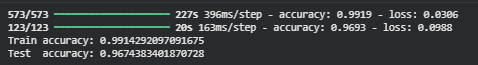

Hasil evaluasi menunjukan performa yang baik dengan akurasi training sebesar 99.14% dan akurasi testing sebesar 96.74%, selisih akurasi relatif kecil antara training dan testing.

## Evaluasi dan Visualisasi

Akurasi


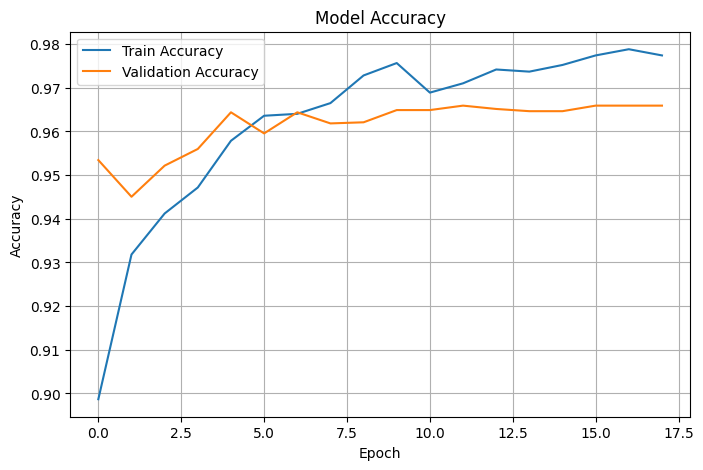


Loss


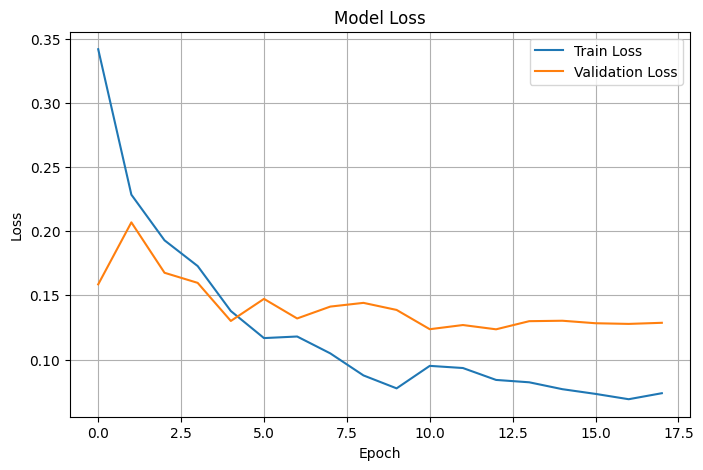

In [18]:
# gabung
def merge_hist(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

acc      = merge_hist(history1, history2, "accuracy")
val_acc  = merge_hist(history1, history2, "val_accuracy")
loss     = merge_hist(history1, history2, "loss")
val_loss = merge_hist(history1, history2, "val_loss")

#accuracy train and validation
print('Akurasi')
plt.figure(figsize=(8, 5))
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Model loss
print('\nLoss')
plt.figure(figsize=(8, 5))
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Konversi Model

saved_model

In [19]:
model.export('saved_model')
print('model berhasil disimpan di', 'saved_model')

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134630933032080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134630933029776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134630933034768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134630933034384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134630933032848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134630933034960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134630933033424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134630933035536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134630933035152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134630933033232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13463093303227

TFlite_model

In [20]:
import os
os.makedirs('tflite', exist_ok=True)

converter = tf.lite.TFLiteConverter.from_saved_model('saved_model')
tflite_model = converter.convert()

with open('tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

print('TFLite disimpan di tflite/model.tflite')

TFLite disimpan di tflite/model.tflite


In [21]:
class_labels = list(train_data.class_indices.keys())

with open('tflite/label.txt', 'w') as f:
    for label in class_labels:
        f.write(label + '\n')

print('Label disimpan di tflite/label.txt')

Label disimpan di tflite/label.txt


tensorflowjs model

In [ ]:
# !pip -q install -U packaging
# !pip -q install -U tensorflowjs

In [24]:
!pip install -q tensorflowjs
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  saved_model \
  tfjs_model/

2026-03-03 19:37:40.500319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772566660.542655   32254 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772566660.566151   32254 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772566660.638156   32254 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772566660.639231   32254 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772566660.639249   32254 computation_placer.cc:177] computation placer alr

## Inference

Output inferensi:



Saving kupu.jpg to kupu.jpg


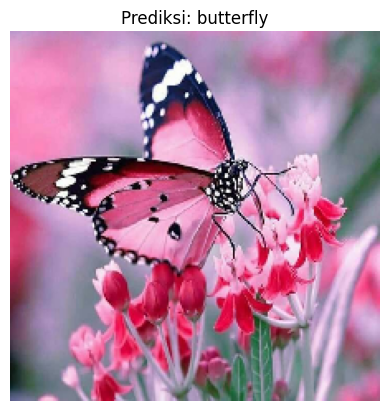

Prediksi kelas: butterfly

Top predictions:
- butterfly: 1.0000
- spider: 0.0000
- chicken: 0.0000


In [28]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files


MODEL_PATH = "tflite/model.tflite"
LABEL_PATH = "tflite/label.txt"


translate = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "scoiattolo": "squirrel",
    "ragno": "spider",
}

en = {v: k for k, v in translate.items()}


OUTPUT_BAHASA = "en"

#  ubah nama hewan kedalam bahasa inggris
def ubah_nama(label_asli: str) -> str:
    if OUTPUT_BAHASA == "en":
        return translate.get(label_asli, label_asli)

# Load Label berfungsi untuk membaca file label label.txt baris per baris
with open(LABEL_PATH, "r") as f:
    labels = [x.strip() for x in f.readlines()]

# load TFLite Model
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH) # load model TFLite ke memori
interpreter.allocate_tensors()
in_det = interpreter.get_input_details()[0] #berfungsi info input model(ukuran gambar,tipe data)
out_det = interpreter.get_output_details()[0] #info output model(jumlah kelas)


H, W = int(in_det["shape"][1]), int(in_det["shape"][2]) #digunakan untuk resize gambar, 1 = height, 2 = width

# Upload dan preprocessing gambar
def inferensi_upload(topk=3): #menampilan hasil 3 prediksi teratas, paling atas adalah hasil prediksi
    uploaded = files.upload() #upload gambar
    img_path = next(iter(uploaded.keys()))

    img = image.load_img(img_path, target_size=(H, W)) #gambar diubah menjadi array
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) #nambah dimensi


    x = tf.keras.applications.mobilenet_v2.preprocess_input(x).astype(np.float32)

# Prediksi
    interpreter.set_tensor(in_det["index"], x) # masukin gambar ke model
    interpreter.invoke() #jalankan prediksi
    probs = interpreter.get_tensor(out_det["index"])[0]


    top_idx = np.argsort(probs)[-topk:][::-1] # -1 berfungsi untuk urutan dari besar ke kecil

    # ambil prediksi terbaik, nilai paling atas diambil
    pred0 = int(top_idx[0])
    label_asli = labels[pred0]
    label_tampil = ubah_nama(label_asli)

    # Tampilkan hasildan judul gambar
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {label_tampil}")
    plt.show()

    print("Prediksi kelas:", label_tampil)
    print("\nTop predictions:")
    for i in top_idx:
        i = int(i)
        la = labels[i]
        lt = ubah_nama(la)
        print(f"- {lt}: {float(probs[i]):.4f}")

inferensi_upload(topk=3)
# hasil prediksi nama hewan akan mengikuti bahasa inggris

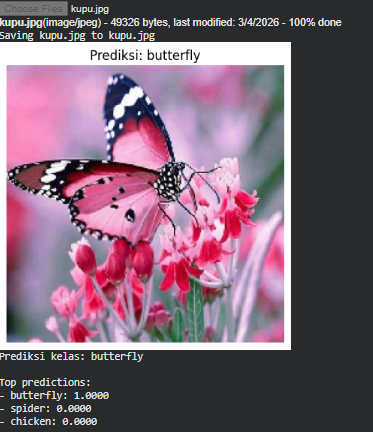

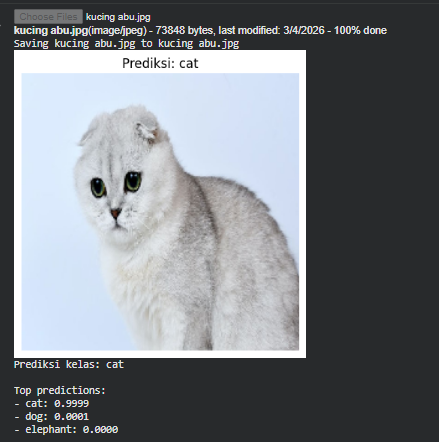

README.md

In [29]:
%%writefile README.md
# Klasifikasi Hewan
Proyek ini bertujuan untuk mengklasifikasikan gambar ke dalam 10 kelas hewan. Model dibuat dengan menggunakan MobileNetV2 berbasis transfer learning.

---

## Ringkasan Proyek
- Dataset berjumlah 26179 gambar
- Model yang digunakan menggunakan TensorFlow + Keras
- Dataset berasal dari kaggle : https://www.kaggle.com/datasets/alessiocorrado99/animals10/data
- Dataset memiliki 10 kelas label
- Model berhasil mencapai akurasi >95% pada data validasi dan pengujian
- Augmentasi Data dapat meningkatkan variasi dan ketahanan model

---

## Struktur Label Kelas
Dataset animal terdiri dari beberapa kelas hewan yang terdiri dari
"cane": "dog","cavallo": "horse","elefante": "elephant","farfalla": "butterfly","gallina": "chicken","gatto": "cat","mucca": "cow","pecora": "sheep","scoiattolo": "squirrel","ragno": "spider"

---
## Format Model
- **SavedModel**
- **TFLite (TensorFlow Lite)**
- **TFJS (TensorFlow.js)**


Writing README.md


requirements.txt

In [30]:
!pip freeze

absl-py==1.4.0
accelerate==1.12.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.2.23.0.48.33
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.8
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.36.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.0.0
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
c

In [31]:
!pip freeze > requirements.txt

In [32]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>